In [4]:
library(readxl)
library(dplyr)
library(ggplot2)
library(patchwork)
library(RColorBrewer)
library(tidyr)
library(readr)

In [5]:
load("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_superclass_pie_without_na_three.Rdata")

In [6]:
meta_anno <- read_tsv("/vol/projects/CIIM/cohorts_old/500FG/metabolic/500FG raw metabolite_fromJianbo.tsv")
head(meta_anno)
dim(meta_anno)

Rows: 1596 Columns: 479
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (5): database_identifier, chemical_formula, smiles, inchi, metabolite_...
dbl (460): mass_to_charge, reliability, HV001, HV002, HV003, HV004, HV005, H...
lgl  (14): fragmentation, modifications, charge, retention_time, taxid, spec...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


database_identifier,chemical_formula,smiles,inchi,metabolite_identification,mass_to_charge,fragmentation,modifications,charge,retention_time,⋯,HV525,HV526,HV527,HV528,HV529,HV530,HV531,HV532,HV533,HV534
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CHEBI:10022,C15H20O6,[H][C@@]12O[C@]3([H])C=C(C)C(=O)[C@@H](O)[C@]3(CO)[C@@](C)(C[C@H]1O)[C@]21CO1,"InChI=1S/C15H20O6/c1-7-3-9-14(5-16,11(19)10(7)18)13(2)4-8(17)12(21-9)15(13)6-20-15/h3,8-9,11-12,16-17,19H,4-6H2,1-2H3/t8-,9-,11-,12-,13-,14-,15+/m1/s1",Deoxynivalenol,295.1191,NA,NA,NA,NA,⋯,18349.0,44987.5,22414.5,19734.0,21075.5,16550.0,20302.0,12916.5,13331.0,36608.0
CHEBI:10075,C16H16O3,COc1cc(O)ccc1C\C=C\c1ccc(O)cc1,"InChI=1S/C16H16O3/c1-19-16-11-15(18)10-7-13(16)4-2-3-12-5-8-14(17)9-6-12/h2-3,5-11,17-18H,4H2,1H3/b3-2+",Xenognosin A,255.1038,NA,NA,NA,NA,⋯,17442.5,23112.5,18458.0,15341.0,17501.0,12886.5,13475.0,20116.5,18011.5,18617.5
CHEBI:10137,C17H26O3,CCCCCCCC(=O)CCc1ccc(O)c(OC)c1,"InChI=1S/C17H26O3/c1-3-4-5-6-7-8-15(18)11-9-14-10-12-16(19)17(13-14)20-2/h10,12-13,19H,3-9,11H2,1-2H3",1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,277.1809,NA,NA,NA,NA,⋯,410828.5,424573.0,784687.0,294914.5,864931.0,356691.0,424070.5,382228.5,465130.0,370595.5
CHEBI:10366,C7H14O4,[H]C([H])(C=O)[C@]([H])(OC)[C@]([H])(O)[C@@]([H])(C)O,"InChI=1S/C7H14O4/c1-5(9)7(10)6(11-2)3-4-8/h4-7,9-10H,3H2,1-2H3/t5-,6+,7-/m1/s1",Cymarose,161.0819,NA,NA,NA,NA,⋯,10493.0,10690.0,10907.5,9893.0,11671.5,10216.5,11271.0,10342.5,10849.5,9935.5
CHEBI:10368,C7H14O5,[H][C@](C)(O)[C@]([H])(O)[C@]([H])(OC)[C@@]([H])(O)C=O,"InChI=1S/C7H14O5/c1-4(9)6(11)7(12-2)5(10)3-8/h3-7,9-11H,1-2H3/t4-,5+,6+,7-/m1/s1",Digitalose,177.0772,NA,NA,NA,NA,⋯,17688.0,14362.5,16077.5,14465.5,19710.0,14843.5,14253.5,15513.0,13962.5,13581.0
CHEBI:10432,C10H8O,Oc1ccc2ccccc2c1,"InChI=1S/C10H8O/c11-10-6-5-8-3-1-2-4-9(8)7-10/h1-7,11H",2-Naphthol,143.0493,NA,NA,NA,NA,⋯,24687.0,20415.5,23917.5,19506.5,20907.0,18360.0,18922.0,19580.0,17712.0,16752.5


[1] 1596  479

In [5]:
meta_class <- read.csv("/vol/projects/yzhang/500FG_aging/input/metabolite/metabolite_superclass_table.csv")
head(meta_class)
dim(meta_class)

,chebi_id,hmdb_id,superclass
,<chr>,<chr>,<chr>
1,CHEBI:28324,HMDB0000015,Lipids and lipid-like molecules
2,CHEBI:16973,HMDB0000016,Lipids and lipid-like molecules
3,CHEBI:17405,HMDB0000017,Organoheterocyclic compounds
4,CHEBI:16530,HMDB0000019,NA
5,CHEBI:18101,HMDB0000020,Benzenoids
6,CHEBI:1582,HMDB0000022,NA


[1] 1603    3

In [11]:
length(intersect(meta_class$chebi_id,meta_anno$database_identifier))
length(unique(meta_class$chebi_id))
length(unique(meta_anno$database_identifier))

[1] 1593

[1] 1593

[1] 1594

In [7]:
meta_cor <- read.csv("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_age_linear_gender_FDR.csv",row.names=1)
head(meta_cor)
dim(meta_cor)

,feature,estimate,p,value,padj,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Estimate,Deoxynivalenol,-0.0021935538,1.463405e-02,-4.024372e-03,3.879725e-02,sig
Estimate1,Xenognosin A,0.0043140324,1.653234e-08,3.357036e-02,2.748502e-07,sig
Estimate2,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,-0.0022477068,8.116900e-02,-2.451371e-03,1.577902e-01,no
Estimate3,Cymarose,0.0002078031,6.635199e-01,3.701929e-05,7.537209e-01,no
Estimate4,Digitalose,0.0009722504,7.081403e-02,1.117972e-03,1.407462e-01,no
Estimate5,2-Naphthol,-0.0009047130,1.127605e-01,-8.575259e-04,2.036774e-01,no


[1] 1596    6

In [45]:
# Save original row order and count of meta_cor (by feature)
feature_order <- meta_cor$feature
n_meta_cor <- nrow(meta_cor)

# ---- 1. Deduplicate meta_anno by metabolite_identification (keep first) ----
dup_anno <- meta_anno[duplicated(meta_anno$metabolite_identification) | duplicated(meta_anno$metabolite_identification, fromLast = TRUE), ]
if (nrow(dup_anno) > 0) {
  dup_anno <- dup_anno[order(dup_anno$metabolite_identification), ]
  message("meta_anno duplicates by metabolite_identification (first/last of each key kept):")
  print(dup_anno)
}
meta_anno_u <- meta_anno[!duplicated(meta_anno$metabolite_identification), ]

# ---- 2. Deduplicate meta_class by chebi_id: prefer superclass non-NA, else any ----
dup_class <- meta_class[duplicated(meta_class$chebi_id) | duplicated(meta_class$chebi_id, fromLast = TRUE), ]
if (nrow(dup_class) > 0) {
    dup_class <- dup_class[order(dup_class$chebi_id, as.integer(is.na(dup_class$superclass))), ]
  message("meta_class duplicates by chebi_id (one row per chebi_id kept, preferring non-NA superclass):")
  print(dup_class)
}
# Order so non-NA superclass comes first per chebi_id, then take first per chebi_id
meta_class_ord <- meta_class[order(meta_class$chebi_id, as.integer(is.na(meta_class$superclass))), ]
meta_class_u <- meta_class_ord[!duplicated(meta_class_ord$chebi_id), ]


meta_class duplicates by chebi_id (one row per chebi_id kept, preferring non-NA superclass):



        chebi_id     hmdb_id                       superclass
223  CHEBI:15647 HMDB0002995  Lipids and lipid-like molecules
142  CHEBI:15647 HMDB0001085                             <NA>
364  CHEBI:16054 HMDB0012127 Phenylpropanoids and polyketides
642  CHEBI:16054 HMDB0142179                             <NA>
640  CHEBI:20106 HMDB0133489                       Benzenoids
51   CHEBI:20106 HMDB0000291                             <NA>
380  CHEBI:28300 HMDB0013240    Organic acids and derivatives
506  CHEBI:28300 HMDB0030886    Organic acids and derivatives
76   CHEBI:30813 HMDB0000511  Lipids and lipid-like molecules
77   CHEBI:30813 HMDB0000513                             <NA>
352  CHEBI:30853 HMDB0011628  Lipids and lipid-like molecules
562  CHEBI:30853 HMDB0034517  Lipids and lipid-like molecules
378  CHEBI:34093 HMDB0013139                       Benzenoids
379  CHEBI:34093 HMDB0013156                       Benzenoids
218  CHEBI:36412 HMDB0002697  Lipids and lipid-like molecules
280  CHE

In [8]:
# ---- 3. Merge: meta_cor as base, row count unchanged ----
meta_cor <- merge(
  meta_cor,
  meta_anno_u[, c("metabolite_identification", "database_identifier")],
  by.x = "feature",
  by.y = "metabolite_identification",
  all.x = TRUE,
  sort = FALSE
)
meta_cor <- merge(
  meta_cor,
  meta_class_u[, c("chebi_id", "superclass")],
  by.x = "database_identifier",
  by.y = "chebi_id",
  all.x = TRUE,
  sort = FALSE
)

# Restore original row order (merge can reorder)
meta_cor <- meta_cor[match(feature_order, meta_cor$feature), ]
rownames(meta_cor) <- NULL

head(meta_cor)
dim(meta_cor)

,database_identifier,feature,estimate,p,value,padj,sig,superclass
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,CHEBI:10022,Deoxynivalenol,-0.0021935538,1.463405e-02,-4.024372e-03,3.879725e-02,sig,Lipids and lipid-like molecules
2,CHEBI:10075,Xenognosin A,0.0043140324,1.653234e-08,3.357036e-02,2.748502e-07,sig,Phenylpropanoids and polyketides
3,CHEBI:10137,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,-0.0022477068,8.116900e-02,-2.451371e-03,1.577902e-01,no,Benzenoids
4,CHEBI:10366,Cymarose,0.0002078031,6.635199e-01,3.701929e-05,7.537209e-01,no,NA
5,CHEBI:10368,Digitalose,0.0009722504,7.081403e-02,1.117972e-03,1.407462e-01,no,NA
6,CHEBI:10432,2-Naphthol,-0.0009047130,1.127605e-01,-8.575259e-04,2.036774e-01,no,Benzenoids


[1] 1596    8

In [9]:
sum(is.na(meta_cor$superclass))

[1] 1022

In [10]:
##remove na
# Replace NA in meta_sig$superclass with "other", save as new object
meta_new <- meta_cor
#meta_new$superclass[is.na(meta_new$superclass)] <- "other"
head(meta_new)
dim(meta_new)

meta_sig <- meta_new[meta_new$sig=="sig",]
head(meta_sig)
dim(meta_sig)

,database_identifier,feature,estimate,p,value,padj,sig,superclass
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,CHEBI:10022,Deoxynivalenol,-0.0021935538,1.463405e-02,-4.024372e-03,3.879725e-02,sig,Lipids and lipid-like molecules
2,CHEBI:10075,Xenognosin A,0.0043140324,1.653234e-08,3.357036e-02,2.748502e-07,sig,Phenylpropanoids and polyketides
3,CHEBI:10137,1-(4-Hydroxy-3-methoxyphenyl)-3-decanone,-0.0022477068,8.116900e-02,-2.451371e-03,1.577902e-01,no,Benzenoids
4,CHEBI:10366,Cymarose,0.0002078031,6.635199e-01,3.701929e-05,7.537209e-01,no,NA
5,CHEBI:10368,Digitalose,0.0009722504,7.081403e-02,1.117972e-03,1.407462e-01,no,NA
6,CHEBI:10432,2-Naphthol,-0.0009047130,1.127605e-01,-8.575259e-04,2.036774e-01,no,Benzenoids


[1] 1596    8

,database_identifier,feature,estimate,p,value,padj,sig,superclass
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,CHEBI:10022,Deoxynivalenol,-0.002193554,1.463405e-02,-0.004024372,3.879725e-02,sig,Lipids and lipid-like molecules
2,CHEBI:10075,Xenognosin A,0.004314032,1.653234e-08,0.033570358,2.748502e-07,sig,Phenylpropanoids and polyketides
9,CHEBI:125536,10-Undecenal,-0.001547591,5.039188e-05,-0.006650986,2.872337e-04,sig,NA
11,CHEBI:131691,LysoPE(0:0/20:0),0.003684064,4.252888e-06,0.019788271,3.294956e-05,sig,Lipids and lipid-like molecules
12,CHEBI:131692,"LysoPE(0:0/20:2(11Z,14Z))",-0.002515251,1.505447e-02,-0.004583628,3.977969e-02,sig,Lipids and lipid-like molecules
14,CHEBI:132966,Hippurate,0.009687998,3.426719e-05,0.043258090,2.018097e-04,sig,NA


[1] 625   8

In [11]:
meta_sig_up <- meta_sig[meta_sig$estimate>0,]
head(meta_sig_up)
dim(meta_sig_up)
meta_sig_down <- meta_sig[meta_sig$estimate<0,]
head(meta_sig_down)
dim(meta_sig_down)

,database_identifier,feature,estimate,p,value,padj,sig,superclass
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,CHEBI:10075,Xenognosin A,0.004314032,1.653234e-08,0.033570358,2.748502e-07,sig,Phenylpropanoids and polyketides
11,CHEBI:131691,LysoPE(0:0/20:0),0.003684064,4.252888e-06,0.019788271,3.294956e-05,sig,Lipids and lipid-like molecules
14,CHEBI:132966,Hippurate,0.009687998,3.426719e-05,0.043258090,2.018097e-04,sig,NA
20,CHEBI:133478,Gibberellin A110,0.004586133,2.018846e-04,0.016945287,9.967921e-04,sig,Lipids and lipid-like molecules
21,CHEBI:133512,Ferulic acid 4-sulfate,0.015729885,3.751520e-12,0.179726403,1.496856e-10,sig,NA
22,CHEBI:133515,LysoPC(16:1(9Z)),0.001796842,9.793208e-04,0.005406833,3.927125e-03,sig,NA


[1] 328   8

,database_identifier,feature,estimate,p,value,padj,sig,superclass
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,CHEBI:10022,Deoxynivalenol,-0.002193554,1.463405e-02,-0.004024372,0.0387972496,sig,Lipids and lipid-like molecules
9,CHEBI:125536,10-Undecenal,-0.001547591,5.039188e-05,-0.006650986,0.0002872337,sig,NA
12,CHEBI:131692,"LysoPE(0:0/20:2(11Z,14Z))",-0.002515251,1.505447e-02,-0.004583628,0.0397796913,sig,Lipids and lipid-like molecules
16,CHEBI:133086,Octadecanedioic acid,-0.002369670,3.004935e-04,-0.008346368,0.0013941499,sig,Lipids and lipid-like molecules
34,CHEBI:135635,Pipazethate,-0.002150960,1.735963e-02,-0.003786679,0.0451237351,sig,Organosulfur compounds
40,CHEBI:136623,Stearoylglycine,-0.001300398,1.475075e-02,-0.002381271,0.0390417746,sig,NA


[1] 297   8

In [12]:
sum(!is.na(meta_sig_up$superclass))
sum(!is.na(meta_sig_down$superclass))

[1] 123

[1] 86

Warning message in brewer.pal(max(n, 3L), "Set3"):
“n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
”


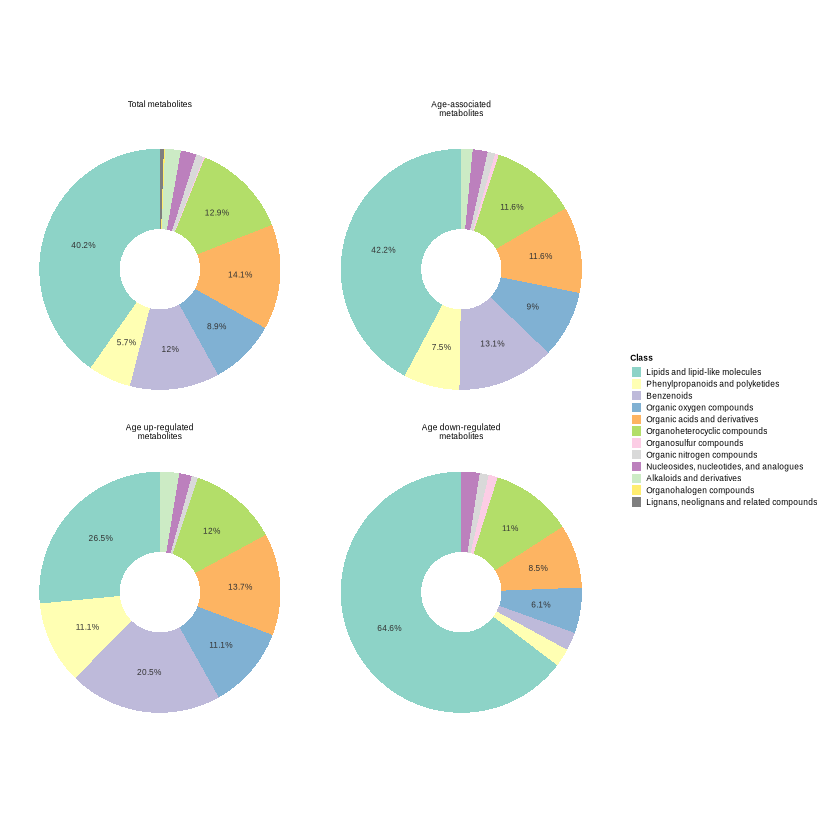

In [88]:
# Shared levels (other last) and palette: Set3 for rest, grey for "other"
# Shared levels (other last) and palette: Set3 for rest, grey for "other"
lv <- unique(c(
  meta_new$superclass,
  meta_sig$superclass,
  meta_sig_up$superclass,
  meta_sig_down$superclass
))
# lv <- c(setdiff(lv, "other"), "other")
n <- length(lv)
# Set3 has max 12; extend with colorRampPalette when n > 12
cols <- setNames(brewer.pal(max(n, 3L), "Set3")[seq_len(n)], lv)

 #Nature Aging style: font size 5 pt in figure
pie_superclass <- function(vec, title = NULL, show_legend = FALSE) {
  d <- as.data.frame(table(vec))
  names(d) <- c("superclass", "n")
  d$superclass <- factor(d$superclass, levels = lv)
  d$pct <- round(d$n / sum(d$n) * 100, 1)
  d$lab <- ifelse(d$pct >= pct_min_show, paste0(d$pct, "%"), "")
  p <- ggplot(d, aes(x = 1, y = n, fill = superclass)) +
    geom_col(width = 1) +
    geom_text(aes(label = lab), position = position_stack(vjust = 0.5), size = 5 / 2.845276, color = "gray20") +
    coord_polar("y") +
    scale_x_continuous(limits = c(0, 1.5), expand = c(0, 0)) +
    scale_fill_manual(values = cols, drop = FALSE,name = "Class") +
    theme_void(base_size = 5) +
    theme(plot.title = element_text(hjust = 0.5, size = 5))
  if (!is.null(title)) p <- p + ggtitle(title)
  if (!show_legend) p <- p + guides(fill = "none")
  p
}

# Titles: Nature style — fix typo (metabolites), concise labels; "age-associated" common in aging lit
p1 <- pie_superclass(meta_new$superclass, "Total metabolites", show_legend = TRUE)
p2 <- pie_superclass(meta_sig$superclass, "Age-associated\nmetabolites")
p3 <- pie_superclass(meta_sig_up$superclass, "Age up-regulated\nmetabolites")
p4 <- pie_superclass(meta_sig_down$superclass, "Age down-regulated\nmetabolites")

# Use Helvetica to match pdf() default (same as your heatmap); cairo_pdf otherwise uses system sans
p_combined <- wrap_plots(p1, p2, p3, p4, nrow = 2, ncol = 2, guides = "collect") &
  theme(
    legend.position = "right",
    legend.key.size = unit(2.5, "mm"),
    legend.spacing.y = unit(1, "mm"),
    legend.text = element_text(size = 5),
    legend.title = element_text(size = 5, face = "bold")
  )

print(p_combined)

# Save PDF: 88 mm width, Nature Aging–style (vector PDF, embedded fonts)
ggsave(
  "/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_superclass_pie_without_na.pdf",
  plot = p_combined,
  width = 88 / 25.4,   # 88 mm in inches
  height = 88 / 25.4 ,  # 2x2 grid, keep aspect
  units = "in"
)



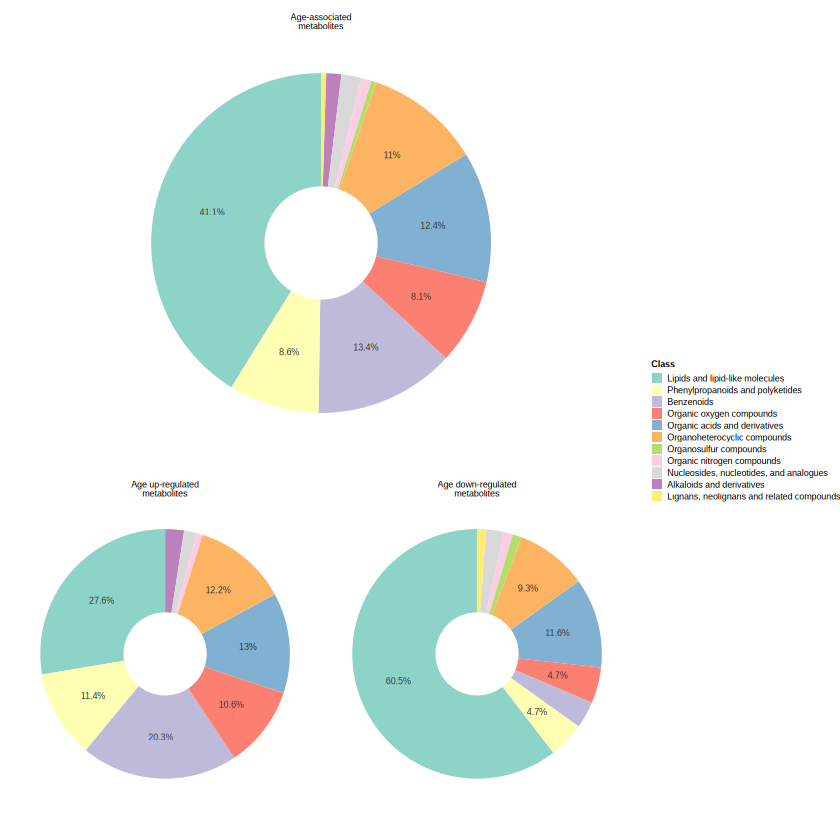

In [13]:
###three pies
pct_min_show <- 4

# Shared levels (other last) and palette: Set3 for rest, grey for "other"
lv <- unique(c(
  meta_new$superclass,
  meta_sig$superclass,
  meta_sig_up$superclass,
  meta_sig_down$superclass
))
lv <- lv[!is.na(lv)]

# lv <- c(setdiff(lv, "other"), "other")
n <- length(lv)
# Set3 has max 12; extend with colorRampPalette when n > 12
cols <- setNames(brewer.pal(max(n, 3L), "Set3")[seq_len(n)], lv)


# Nature Aging style: font size 5 pt in figure
pie_superclass <- function(vec, title = NULL, show_legend = FALSE) {
  d <- as.data.frame(table(vec))
  names(d) <- c("superclass", "n")
  d$superclass <- factor(d$superclass, levels = lv)
  d$pct <- round(d$n / sum(d$n) * 100, 1)
  d$lab <- ifelse(d$pct >= pct_min_show, paste0(d$pct, "%"), "")
  p <- ggplot(d, aes(x = 1, y = n, fill = superclass)) +
    geom_col(width = 1) +
    geom_text(aes(label = lab), position = position_stack(vjust = 0.5), size = 5 / 2.845276, color = "gray20", family = "Helvetica") +
    coord_polar("y") +
    scale_x_continuous(limits = c(0, 1.5), expand = c(0, 0)) +
    scale_fill_manual(values = cols, drop = TRUE, name = "Class") +
    theme_void(base_size = 5, base_family = "Helvetica") +
    theme(plot.title = element_text(hjust = 0.5, size = 5))
  if (!is.null(title)) p <- p + ggtitle(title)
  if (!show_legend) p <- p + guides(fill = "none")
  p
}

p2 <- pie_superclass(meta_sig$superclass, "Age-associated\nmetabolites", show_legend = TRUE)  # legend for p2+p3+p4 layout
p3 <- pie_superclass(meta_sig_up$superclass, "Age up-regulated\nmetabolites")
p4 <- pie_superclass(meta_sig_down$superclass, "Age down-regulated\nmetabolites")

# Layout: only p2, p3, p4 — p2 row1 (larger), p3+p4 row2 (smaller)
p_combined <- wrap_plots(
  p2,
  wrap_plots(p3, p4, ncol = 2),
  nrow = 2,
  heights = c(1.2, 1),
  guides = "collect"
) &
  theme(
    legend.position = "right",
    legend.key.size = unit(2.5, "mm"),
    legend.spacing.y = unit(1, "mm"),
    legend.text = element_text(size = 5),
    legend.title = element_text(size = 5, face = "bold")
  )

print(p_combined)
ggsave(
  "/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_superclass_pie_without_na_three_gender.pdf",
  plot = p_combined,
  width = 88 / 25.4,   # 88 mm in inches
  height = 55 / 25.4,
  units = "in"
)

In [14]:
save.image("/vol/projects/yzhang/500FG_aging/output/03_metabolite/metabolite_superclass_pie_without_na_three_gender.Rdata")